Análise de Dados dos servidores da prefeitura de Ipatinga-MG (Maio de 2024)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar os dados
df = pd.read_csv('E:/Estacio/3º periodo/Análise De Dados/Trabalho de extensão/Analise_de_dados/servidores_ipatinga.csv')

# fonte: https://dadosabertos-portalfacil.azurewebsites.net/97/servidores
# Relação de todos os pagamentos, descontos, proventos e demais informações a respeito dos gastos com os servidores do órgão. 
# Referência (Competência): 05/2024

In [2]:
# Verificando valores ausentes em 'DESCUNIDADE' e 'VLLIQUIDO'.
df.isnull().sum()  

NUMMATRICULA               0
DESCSERVIDOR               0
DESCUNIDADE                0
DESCCARGO                  0
DESCFUNCAO              9657
DESCVINCULO                0
DESCSITUACAOCONTRATO    9657
DESCTPFOLHA                0
COVID                      0
DTCOMPETENCIA              0
VLBASE                     0
VLPROVENTO                 0
VLDESCONTO                 0
VLLIQUIDO                  0
dtype: int64

In [3]:
# Verificando se há algum dado com valor zero. como não há, devido pré-tratamento, 
# Na coluna 'VLLIQUIDO', as 381 linhas com valor zero foram retiradas.
print('valores zero em VLLIQUIDO: ', (df['VLLIQUIDO'] == 0).sum())

valores zero em VLLIQUIDO:  0


In [4]:
# Informações gerais
total_servidores = len(df)
total_pagamentos = round(df['VLLIQUIDO'].sum(), 2)
print(f'População analisada: {total_servidores} servidores da Prefeitura de Ipatinga.')
print(f'Soma Total dos valores recebidos em Maio de 2024: R$ {total_pagamentos:.2f}')


População analisada: 9657 servidores da Prefeitura de Ipatinga.
Soma Total dos valores recebidos em Maio de 2024: R$ 30397512.05


Neste trecho, agrupo os servidores por unidade (DESCUNIDADE), somo os valores salariais (VLLIQUIDO) e ordeno em ordem decrescente.  
Isso permite visualizar quais setores têm a maior soma de pagamentos, ajudando na análise da distribuição de recursos da prefeitura.

In [5]:

# Soma dos valores recebidos por setor
pagamento_por_setor = df.groupby('DESCUNIDADE')['VLLIQUIDO'].sum().sort_values(ascending=False)
print("\nSoma dos valores recebidos pelos servidores em cada Unidade:")
print(pagamento_por_setor)


Soma dos valores recebidos pelos servidores em cada Unidade:
DESCUNIDADE
SECRETARIA MUNICIPAL DE EDUCACAO            13059090.43
SECRETARIA MUNICIPAL DE SAUDE               11583468.05
SECRETARIA M DE SEGURANCA E CONV CIDADÃ      1409744.94
SECRETARIA MUNICIPAL DE ADMINISTRACAO         796462.14
SECRETARIA MUNICIPAL DE SERV.URBANOS E M      614026.67
SECRETARIA MUNICIPAL DE FAZENDA               509620.17
PROCURADORIA GERAL                            360220.86
SECRETARIA MUNICIPAL ASSISTENCIA SOCIAL       341842.73
SECRETARIA MUNICIPAL DE DADOS                 286791.12
SECRETARIA MUNICIPAL DE OBRAS PUBLICAS        268591.43
SECRETARIA M DE CULTURA, ESPORTE E LAZER      262061.05
SECRETARIA MUNICIPAL DE PLANEJAMENTO          245015.07
RECURSOS SUPERVISIONADOS                      140886.68
FUNDO MUN DA ASSISTENCIA SOCIAL               134528.55
SECRETARIA MUNIC DE COMUNICACAO SOCIAL         99401.03
SECRETARIA MUNICIPAL EXECUTIVA                 77011.84
SECRETARIA M DE DESENV ECON E 

In [6]:
print('Distribuição dos servidores, de acordo com a Unidade em que trabalham: ')
print(df['DESCUNIDADE'].value_counts())

Distribuição dos servidores, de acordo com a Unidade em que trabalham: 
DESCUNIDADE
SECRETARIA MUNICIPAL DE EDUCACAO            4570
SECRETARIA MUNICIPAL DE SAUDE               3263
SECRETARIA M DE SEGURANCA E CONV CIDADÃ      413
SECRETARIA MUNICIPAL DE ADMINISTRACAO        321
SECRETARIA MUNICIPAL DE SERV.URBANOS E M     222
SECRETARIA MUNICIPAL DE FAZENDA              160
SECRETARIA MUNICIPAL ASSISTENCIA SOCIAL      127
SECRETARIA MUNICIPAL DE OBRAS PUBLICAS       103
SECRETARIA M DE CULTURA, ESPORTE E LAZER      82
RECURSOS SUPERVISIONADOS                      68
SECRETARIA MUNICIPAL DE DADOS                 64
PROCURADORIA GERAL                            63
SECRETARIA MUNICIPAL DE PLANEJAMENTO          60
FUNDO MUN DA ASSISTENCIA SOCIAL               53
SECRETARIA MUNIC DE COMUNICACAO SOCIAL        21
SECRETARIA MUNICIPAL EXECUTIVA                18
SECRETARIA M DE DESENV ECON E TURISMO         15
GABINETE DO CHEFE DO PODER EXECUTIVO          12
CONTROLADORIA GERAL DO MUNICIPIO  

O código conta a frequência de valores na coluna 'DESCUNIDADE' do DataFrame df e cria um gráfico de barras horizontais para mostrar a distribuição desses valores.  
Ele adiciona título e rótulos aos eixos, e exibe o gráfico.

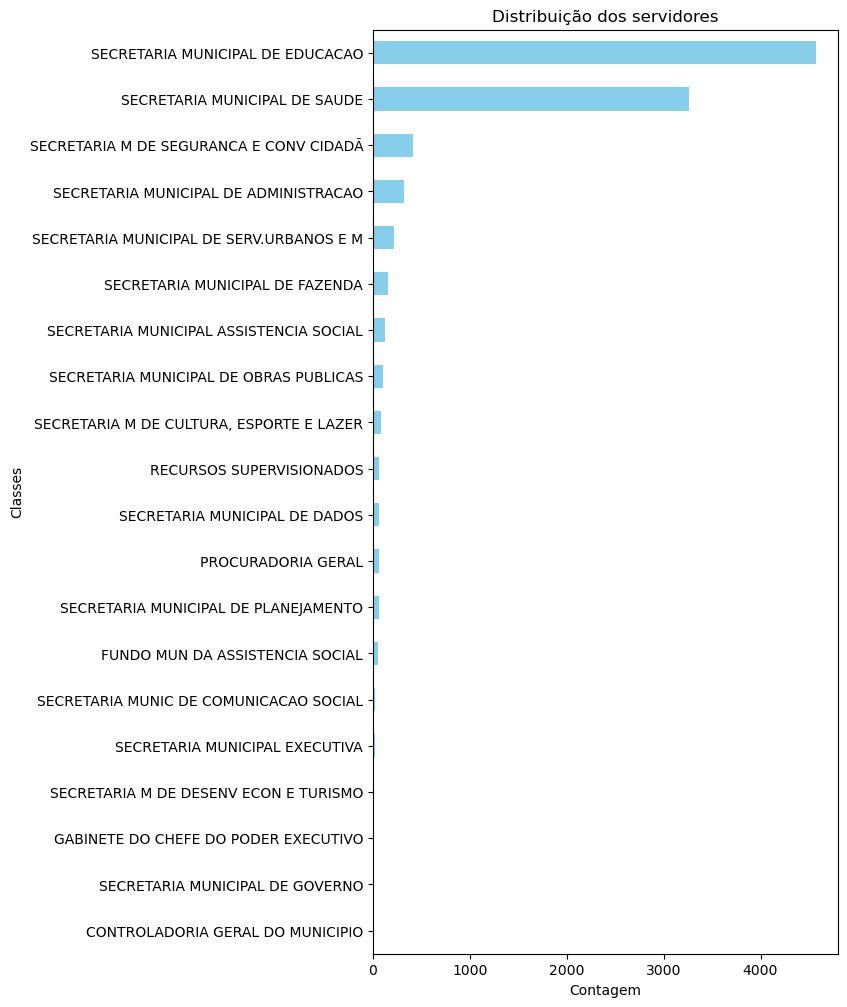

In [ ]:
servidores_f = df['DESCUNIDADE'].value_counts(ascending=True)

plt.figure(figsize=(6, 12))

servidores_f.plot(kind='barh', color='skyblue')

# Adiciona título e rótulos aos eixos
plt.title('Distribuição dos servidores')
plt.ylabel('Classes')
plt.xlabel('Contagem')

# Mostra o gráfico
plt.show()

O código calcula a mediana do valor líquido ('VLLIQUIDO') por unidade ('DESCUNIDADE'), agrupando os dados por unidade com groupby.  
Em seguida, ordena as medianas de forma decrescente e imprime o resultado.

In [8]:
# Cálculo das medianas por unidade
mediana_por_setor = df.groupby('DESCUNIDADE')['VLLIQUIDO'].median().sort_values(ascending=False)
print("\nMediana salarial por unidade:")
print(mediana_por_setor)


Mediana salarial por unidade:
DESCUNIDADE
CONTROLADORIA GERAL DO MUNICIPIO            5701.260
SECRETARIA MUNIC DE COMUNICACAO SOCIAL      4985.950
PROCURADORIA GERAL                          4572.240
SECRETARIA MUNICIPAL DE PLANEJAMENTO        4132.000
SECRETARIA M DE DESENV ECON E TURISMO       4122.830
SECRETARIA MUNICIPAL EXECUTIVA              4122.830
SECRETARIA MUNICIPAL DE DADOS               3864.910
SECRETARIA M DE SEGURANCA E CONV CIDADÃ     3533.000
SECRETARIA MUNICIPAL DE GOVERNO             3129.620
SECRETARIA MUNICIPAL DE FAZENDA             2986.355
SECRETARIA MUNICIPAL DE SAUDE               2950.730
SECRETARIA M DE CULTURA, ESPORTE E LAZER    2896.635
GABINETE DO CHEFE DO PODER EXECUTIVO        2793.045
SECRETARIA MUNICIPAL ASSISTENCIA SOCIAL     2764.070
SECRETARIA MUNICIPAL DE SERV.URBANOS E M    2761.170
FUNDO MUN DA ASSISTENCIA SOCIAL             2672.540
SECRETARIA MUNICIPAL DE EDUCACAO            2463.900
SECRETARIA MUNICIPAL DE OBRAS PUBLICAS      2096.900
SEC

O código calcula a amplitude salarial, que é a diferença entre a maior e a menor mediana salarial por unidade.  
Ele encontra a maior e a menor mediana usando max() e min(), e depois calcula a diferença.  
Em seguida, imprime os resultados: o nome da unidade com a maior e a menor mediana, além da amplitude salarial.

In [9]:
# Cálculo da amplitude salarial
maior_mediana = mediana_por_setor.max()
menor_mediana = mediana_por_setor.min()
amplitude = maior_mediana - menor_mediana

print("\nAnálise da amplitude salarial:")
print(f"Maior Mediana: {mediana_por_setor.idxmax()}: R$ {maior_mediana:,.2f}")
print(f"Menor Mediana: {mediana_por_setor.idxmin()}: R$ {menor_mediana:,.2f}")
print(f"Amplitude Salarial: R$ {amplitude:,.2f}")


Análise da amplitude salarial:
Maior Mediana: CONTROLADORIA GERAL DO MUNICIPIO: R$ 5,701.26
Menor Mediana: RECURSOS SUPERVISIONADOS: R$ 1,223.04
Amplitude Salarial: R$ 4,478.22


O código realiza uma análise de dispersão para os setores de Educação e Saúde.  
Para cada setor, ele calcula a média, variância, desvio padrão, coeficiente de variação, quartis (Q1, mediana e Q3) e os limites superior e inferior com base no IQR (intervalo interquartil). 

Além disso, ele gera e exibe um boxplot para visualizar a distribuição dos salários líquidos de cada setor.  

Os resultados estatísticos e o gráfico são impressos e exibidos para cada um dos setores analisados.


Análise para SECRETARIA MUNICIPAL DE EDUCACAO:
Média Salarial: R$ 2857.57
Variância: R$ 2768113.34
Desvio Padrão: R$ 1663.76
Coeficiente de Variação: 58.22%
Q1: R$ 1572.87, Q2 (Mediana): R$ 2463.90, Q3: R$ 3942.86
Limite Superior: R$ 7497.83, Limite Inferior: R$ 3.19


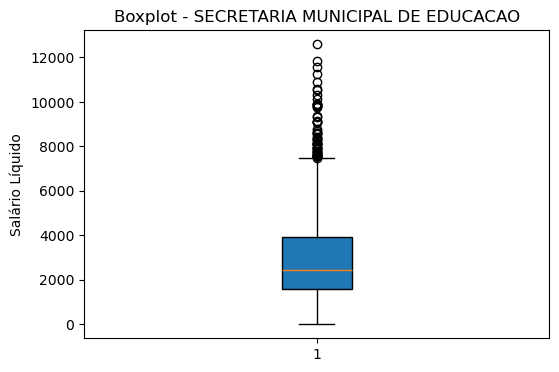


Análise para SECRETARIA MUNICIPAL DE SAUDE:
Média Salarial: R$ 3549.94
Variância: R$ 6802219.39
Desvio Padrão: R$ 2608.11
Coeficiente de Variação: 73.47%
Q1: R$ 2177.60, Q2 (Mediana): R$ 2950.73, Q3: R$ 3923.10
Limite Superior: R$ 6541.35, Limite Inferior: R$ 5.80


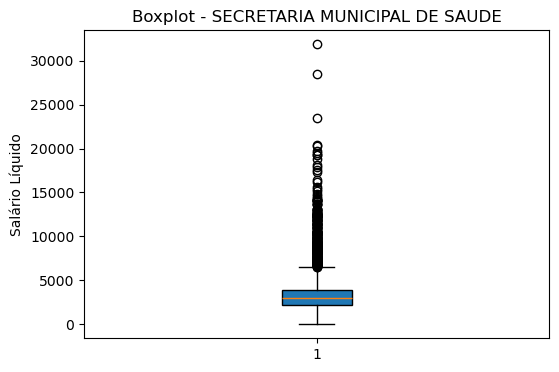

In [10]:

# Análise de dispersão para Educação e Saúde
setores_analise = ['SECRETARIA MUNICIPAL DE EDUCACAO', 'SECRETARIA MUNICIPAL DE SAUDE']
for setor in setores_analise:
    salarios = df[df['DESCUNIDADE'] == setor]['VLLIQUIDO']
    media = salarios.mean()
    variancia = salarios.var()
    desvio_padrao = salarios.std()
    coef_var = (desvio_padrao / media) * 100
    estatisticas = salarios.describe()
    IQR = estatisticas['75%'] - estatisticas['25%']
    limite_superior = estatisticas['75%'] + 1.5 * IQR
    limite_inferior = max(estatisticas['min'], estatisticas['25%'] - 1.5 * IQR)
    
    print(f"\nAnálise para {setor}:")
    print(f"Média Salarial: R$ {media:.2f}")
    print(f"Variância: R$ {variancia:.2f}")
    print(f"Desvio Padrão: R$ {desvio_padrao:.2f}")
    print(f"Coeficiente de Variação: {coef_var:.2f}%")
    print(f"Q1: R$ {estatisticas['25%']:.2f}, Q2 (Mediana): R$ {estatisticas['50%']:.2f}, Q3: R$ {estatisticas['75%']:.2f}")
    print(f"Limite Superior: R$ {limite_superior:.2f}, Limite Inferior: R$ {limite_inferior:.2f}")
    
    # Boxplot
    plt.figure(figsize=(6, 4))
    plt.boxplot(salarios, vert=True, patch_artist=True)
    plt.title(f"Boxplot - {setor}")
    plt.ylabel("Salário Líquido")
    plt.show()